# Aprendizaje No Supervisado

## Objetivo

Comprender cómo detectar estructuras y patrones en datos **sin etiquetas** mediante técnicas de clustering y reducción de dimensionalidad.

## Contenidos del trabajo práctico

1. Diferencias entre aprendizaje supervisado y no supervisado
2. Preparación y escalado de datos para clustering
3. Algoritmo **K-Means**
4. Elbow Method y Silhouette Score para elegir el K óptimo
5. **PCA** aplicado a visualización de clusters




---
## Imports y configuración inicial

Ejecutá la siguiente celda para importar todas las librerías necesarias.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Parte 1: Supervisado vs. No Supervisado

### Conceptos teóricos

| Característica | Aprendizaje Supervisado | Aprendizaje No Supervisado |
|---|---|---|
| **Etiquetas (y)** | Sí, disponibles | No, no existen |
| **Objetivo** | Predecir una variable target | Descubrir estructura oculta |
| **Ejemplos de algoritmos** | Regresión Lineal, Random Forest | K-Means, DBSCAN, PCA |
| **Validación** | Métricas con ground truth (accuracy, RMSE) | Métricas internas (silhouette, inercia) |
| **Casos de uso** | Clasificación de spam, predicción de precio | Segmentación de clientes, detección de anomalías |

### Ejercicio 1.1 – Solución orientativa

**a)** Es más difícil evaluar un modelo no supervisado porque no existe una etiqueta real contra la cual comparar. La inercia y Silhouette aportan evidencia interna, pero un agrupamiento compacto no necesariamente es útil para el problema real. También se necesita interpretación del dominio.

**b)** Dos ejemplos:

1. **Segmentación de clientes:** no conocemos previamente el segmento de cada persona; buscamos descubrir grupos con comportamientos semejantes.
2. **Detección exploratoria de anomalías:** si no existe un historial confiable de casos etiquetados, se buscan observaciones alejadas de los patrones frecuentes.

> **Para debatir:** una buena métrica no garantiza que los clusters sean accionables. ¿Ayudan a tomar una decisión concreta?


---
## Parte 2: Dataset – Segmentación de Clientes

Vamos a trabajar con un dataset simulado de clientes de un e-commerce con las siguientes variables:

- `edad`: edad del cliente
- `ingreso_anual`: ingreso anual estimado (en miles de $)

- `gasto_mensual`: gasto mensual promedio en la plataforma (en $)
- `frecuencia_compras`: cantidad de compras en el último año
- `antiguedad_meses`: meses que lleva siendo cliente

### Carga del dataset

In [ ]:
np.random.seed(42)
n = 300

# Generamos 3 grupos de clientes con perfiles distintos
grupo_1 = pd.DataFrame({
    'edad': np.random.normal(25, 4, 100).astype(int),
    'ingreso_anual': np.random.normal(30, 5, 100),
    'gasto_mensual': np.random.normal(80, 15, 100),
    'frecuencia_compras': np.random.normal(5, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(12, 4, 100).astype(int)
})

grupo_2 = pd.DataFrame({
    'edad': np.random.normal(40, 5, 100).astype(int),
    'ingreso_anual': np.random.normal(70, 10, 100),
    'gasto_mensual': np.random.normal(250, 40, 100),
    'frecuencia_compras': np.random.normal(15, 3, 100).astype(int),
    'antiguedad_meses': np.random.normal(36, 8, 100).astype(int)
})

grupo_3 = pd.DataFrame({
    'edad': np.random.normal(55, 6, 100).astype(int),
    'ingreso_anual': np.random.normal(55, 8, 100),
    'gasto_mensual': np.random.normal(150, 25, 100),
    'frecuencia_compras': np.random.normal(8, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(60, 12, 100).astype(int)
})

df = pd.concat([grupo_1, grupo_2, grupo_3], ignore_index=True)
df = df.clip(lower=0)  # evitar valores negativos

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (300, 5)


,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
0,26,22.923146,85.366810,3,5
1,24,27.896773,88.411768,3,9
2,27,28.286427,96.245769,6,12
3,31,25.988614,95.807031,6,12
4,24,29.193571,59.334959,4,10
5,24,32.020254,65.932624,5,14
6,31,39.430930,87.725529,7,7
7,28,30.872889,87.706789,3,11
8,23,31.287752,87.725715,6,12
9,27,29.627770,137.790972,4,14


### Ejercicio 2.1 – Exploración inicial

In [ ]:
# describe() resume tendencia central, dispersión y rango de cada variable.
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
edad,300.0,39.50,13.67,14.00,26.00,38.50,52.00,67.00
ingreso_anual,300.0,52.07,18.65,20.41,32.56,54.91,66.59,95.73
gasto_mensual,300.0,160.62,74.88,31.38,91.11,151.06,221.18,355.30
frecuencia_compras,300.0,9.11,4.97,0.00,5.00,8.00,13.00,22.00
antiguedad_meses,300.0,36.55,22.74,2.00,14.00,36.00,53.25,91.00


In [ ]:
# isnull() detecta faltantes; sum() los cuenta por columna.
nulos = df.isnull().sum()
print('Valores nulos por variable:')
print(nulos)
print(f'\nTotal: {nulos.sum()}')


Valores nulos por variable:
edad                  0
ingreso_anual         0
gasto_mensual         0
frecuencia_compras    0
antiguedad_meses      0
dtype: int64

Total: 0


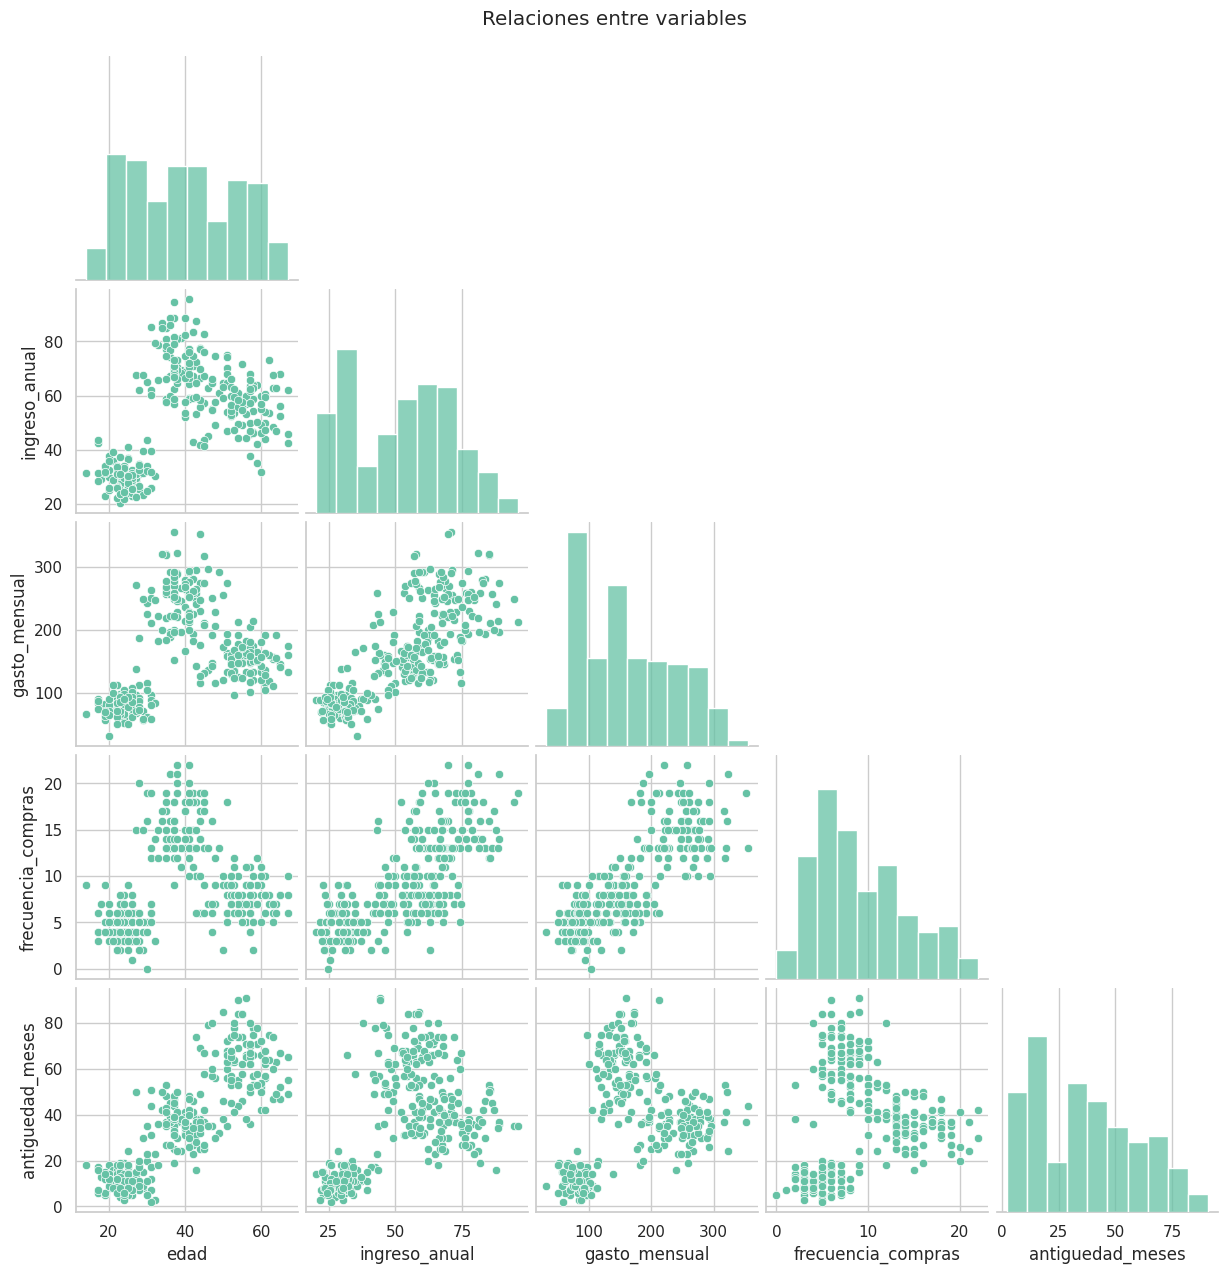

In [ ]:
# La diagonal muestra distribuciones; el resto, relaciones entre pares.
sns.pairplot(df, corner=True, diag_kind='hist')
plt.suptitle('Relaciones entre variables', y=1.02)
plt.show()


---
## Parte 3: Escalado de datos

El clustering es sensible a la escala de las variables. Antes de aplicar K-Means, debemos **estandarizar** los datos.

### ¿Por qué escalar?

K-Means calcula distancias euclidianas. Si `ingreso_anual` tiene valores en el rango 20–90 y `frecuencia_compras` en el rango 1–25, la variable de mayor escala domina el cálculo y **distorsiona los clusters**.

In [ ]:
# Escalado con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print('Datos escalados')
X_scaled.describe().T.round(2)

Datos escalados


,count,mean,std,min,25%,50%,75%,max
edad,300.0,-0.0,1.0,-1.87,-0.99,-0.07,0.92,2.02
ingreso_anual,300.0,0.0,1.0,-1.70,-1.05,0.15,0.78,2.35
gasto_mensual,300.0,-0.0,1.0,-1.73,-0.93,-0.13,0.81,2.60
frecuencia_compras,300.0,-0.0,1.0,-1.83,-0.83,-0.22,0.78,2.60
antiguedad_meses,300.0,0.0,1.0,-1.52,-0.99,-0.02,0.74,2.40


### Ejercicio 3.1 – Comparación antes y después del escalado

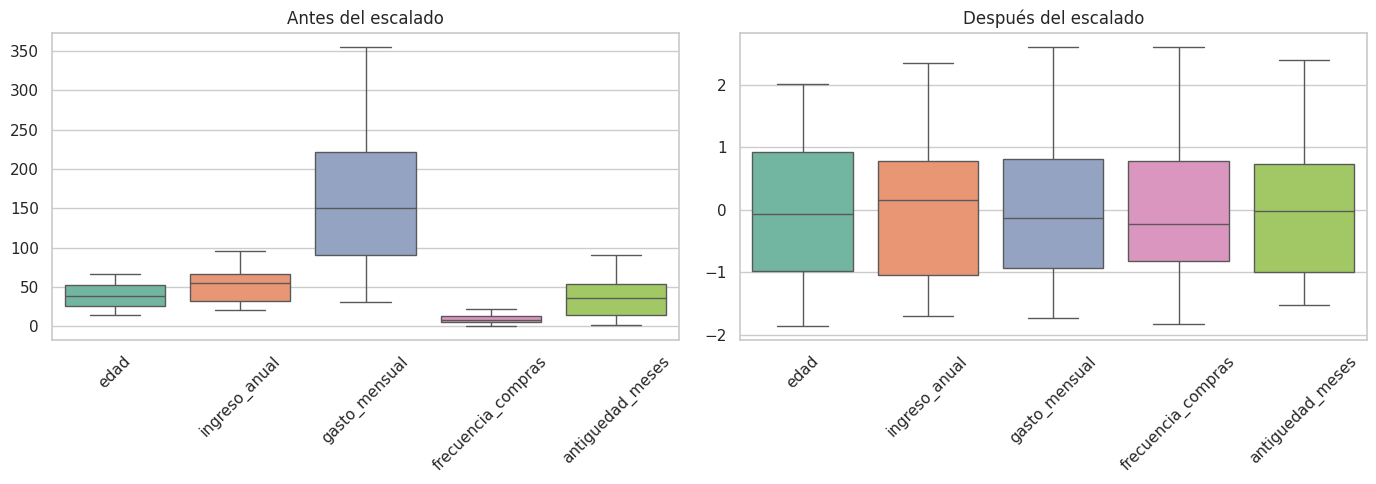

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, ax=axes[0])
axes[0].set_title('Antes del escalado')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=X_scaled, ax=axes[1])
axes[1].set_title('Después del escalado')
axes[1].tick_params(axis='x', rotation=45)

# StandardScaler produce media ≈ 0 y desvío ≈ 1; no limita entre 0 y 1.
plt.tight_layout(); plt.show()


---
## Parte 4: Algoritmo K-Means

### ¿Cómo funciona K-Means?

1. Se eligen **K centroides** aleatoriamente
2. Cada punto se asigna al centroide más cercano → se forman K clusters
3. Se recalculan los centroides como la **media** de los puntos asignados
4. Se repiten los pasos 2 y 3 hasta que los centroides no cambian (convergencia)

**Inercia** (Within-Cluster Sum of Squares – WCSS): suma de las distancias al cuadrado de cada punto a su centroide. A menor inercia → clusters más compactos.

### Aplicando K-Means con K=3

In [ ]:
# Entrenamos K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Asignamos las etiquetas de cluster al dataframe original
df['cluster'] = kmeans.labels_
X_scaled['cluster'] = kmeans.labels_

print(f'Inercia del modelo: {kmeans.inertia_:.2f}')
print(f'\nDistribución de clusters:')
print(df['cluster'].value_counts().sort_index())

Inercia del modelo: 244.55

Distribución de clusters:
cluster
0     99
1    100
2    101
Name: count, dtype: int64


In [ ]:
df

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses,cluster
0,26,22.923146,85.366810,3,5,1
1,24,27.896773,88.411768,3,9,1
2,27,28.286427,96.245769,6,12,1
3,31,25.988614,95.807031,6,12,1
4,24,29.193571,59.334959,4,10,1
...,...,...,...,...,...,...
295,54,58.523798,147.527759,8,84,0
296,55,54.842898,172.976912,5,84,0
297,43,59.419920,142.743136,6,74,0
298,60,56.791313,156.684808,10,72,0


In [ ]:
X_scaled

NameError: name 'X_scaled' is not defined

Ejercicio 4.1 – Perfil de cada cluster

Calculá el promedio de cada variable por cluster e interpretá qué tipo de cliente representa cada grupo.

In [ ]:
# Usamos unidades originales para obtener perfiles interpretables.
perfil_clusters = df.groupby('cluster').mean().round(2)
perfil_clusters


,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
cluster,,,,,
0,55.66,55.68,151.13,7.44,62.86
1,24.14,30.11,80.97,4.69,11.27
2,38.86,70.27,248.78,15.11,35.79


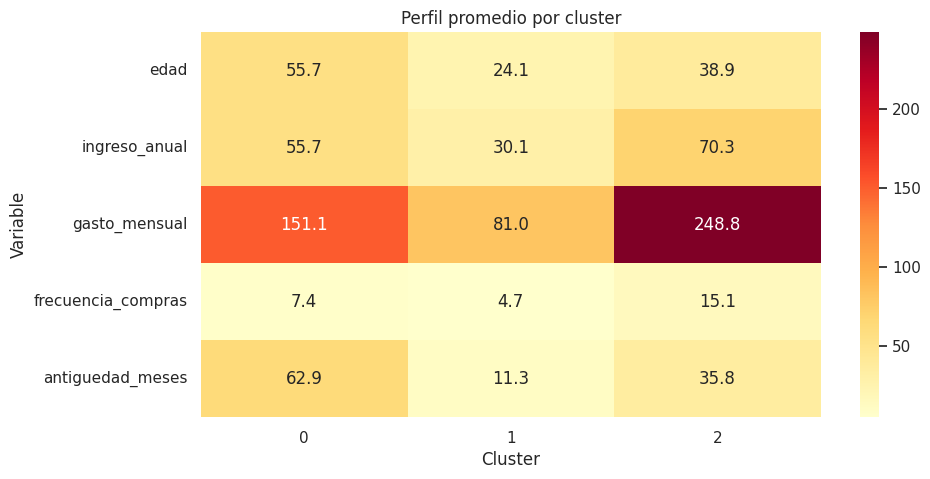

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(perfil_clusters.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Perfil promedio por cluster')
plt.xlabel('Cluster'); plt.ylabel('Variable')
plt.tight_layout();
plt.show()


**Interpretación esperada**

Relacioná cada número de cluster con uno de estos perfiles, según la tabla obtenida:

- **Clientes jóvenes y nuevos:** menor edad, ingreso, gasto, frecuencia y antigüedad.
- **Clientes de alto valor y actividad:** ingreso, gasto y frecuencia elevados.
- **Clientes maduros y antiguos:** mayor edad y antigüedad, con consumo intermedio.

> K-Means puede intercambiar los números asignados sin cambiar los grupos. Por eso siempre se leen los centroides o promedios.


---
## Parte 5: Elbow Method y Silhouette Score

### El problema de elegir K

No siempre sabemos cuántos grupos tiene el dataset. Usamos dos métodos para encontrar el K óptimo:

- **Elbow Method**: graficamos la inercia para distintos valores de K. El "codo" de la curva indica el K óptimo.
- **Silhouette Score**: mide qué tan bien asignado está cada punto (rango: -1 a 1). Un valor cercano a 1 indica que el punto está bien asignado a su cluster.

### ¿Ejercicio 5.1 – Implementar Elbow Method

In [ ]:
# Para Elbow incluimos K=1, que sirve como punto inicial de comparación.
inercias = []
k_range = range(1, 11)
X_modelo = X_scaled.drop('cluster', axis=1)

for k in k_range:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_k.fit(X_modelo)
    inercias.append(modelo_k.inertia_)

plt.plot(list(k_range), inercias, 'o-')
plt.title('Elbow Method – Selección del K óptimo')
plt.xlabel('Número de clusters (K)'); plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range)); plt.show()

# La inercia siempre baja al aumentar K. Buscamos dónde la mejora deja de ser marcada.


NameError: name 'X_scaled' is not defined

### Ejercicio 5.2 – Implementar Silhouette Score


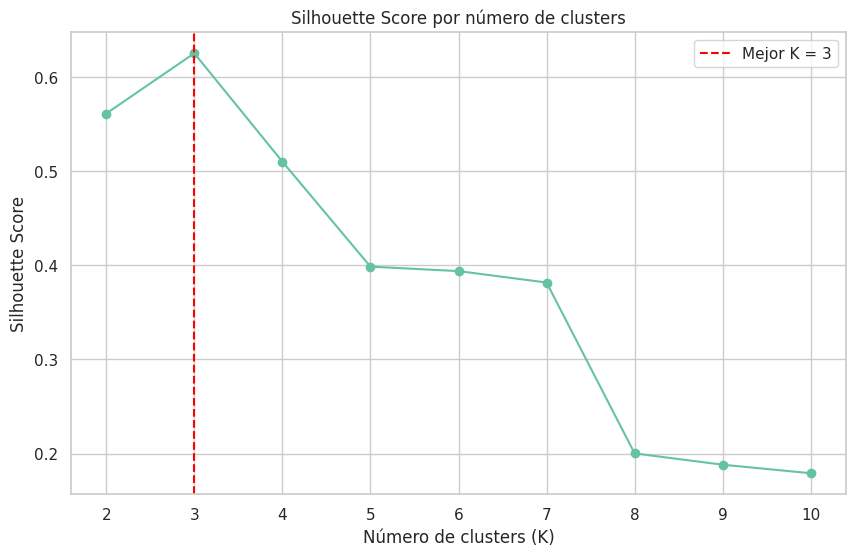

Mejor score: 0.625 para K = 3


In [ ]:
# Silhouette requiere al menos 2 clusters.
k_range_silhouette = range(2, 11)
silhouette_scores = []

for k in k_range_silhouette:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_modelo)
    silhouette_scores.append(silhouette_score(X_modelo, labels_k))

mejor_i = int(np.argmax(silhouette_scores))
mejor_k = list(k_range_silhouette)[mejor_i]
mejor_score = silhouette_scores[mejor_i]

plt.plot(list(k_range_silhouette), silhouette_scores, 'o-')
plt.axvline(mejor_k, color='red', linestyle='--',
            label=f'Mejor resultado: K = {mejor_k}')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_silhouette))
plt.legend()
plt.show()

print(f'Mejor score explorado: {mejor_score:.3f} para K = {mejor_k}')

**Conclusión orientativa:**

- El codo debería aparecer alrededor de **K = 3**.
- El valor exacto del mejor Silhouette se obtiene al ejecutar el notebook.
- Elegimos K combinando métricas, estabilidad e interpretabilidad; no aplicando una regla automática.


---
## Parte 6: PCA aplicado a visualización de clusters

Nuestro dataset tiene 5 dimensiones. Para visualizar los clusters en 2D, usamos **PCA** (Análisis de Componentes Principales), que reduce las dimensiones preservando la mayor varianza posible.

### ¿Qué es PCA?

PCA encuentra nuevas variables (componentes principales) que son **combinaciones lineales** de las originales, ordenadas por la cantidad de varianza que explican. Las primeras dos componentes nos permiten proyectar el dataset en un plano 2D.

In [ ]:
# Aplicamos PCA a 2 componentes
X_sin_cluster = X_scaled.drop('cluster', axis=1)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sin_cluster)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_explicada[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_explicada[1]:.2%}')
print(f'Varianza total explicada: {sum(varianza_explicada):.2%}')

Varianza explicada por PC1: 62.46%
Varianza explicada por PC2: 27.32%
Varianza total explicada: 89.78%


### Visualizar clusters con PCA


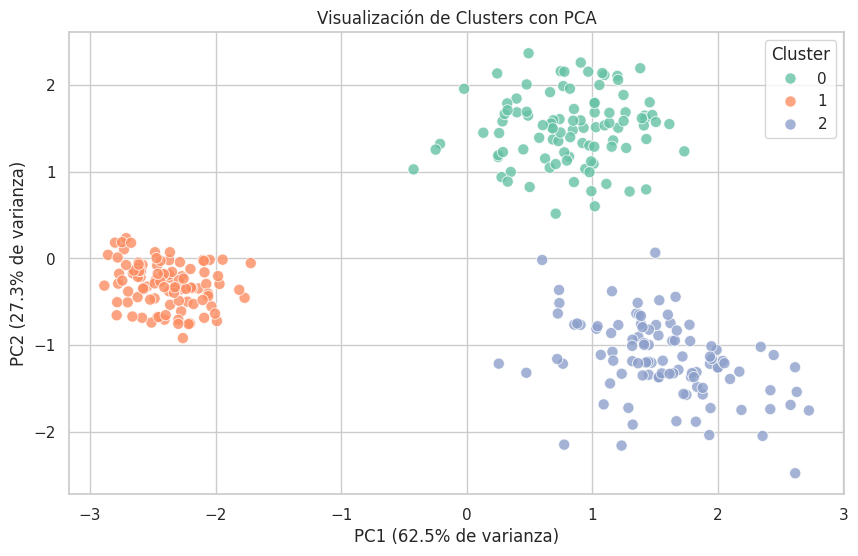

In [ ]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].to_numpy()

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster',
                palette='Set2', s=65, alpha=0.8)
plt.title('Visualización de Clusters con PCA')
plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} de varianza)')
plt.legend(title='Cluster'); plt.show()

# PCA solo proyecta para visualizar; K-Means usó las cinco variables escaladas.


### Loadings de PCA - Variables que contribuyen más

Los **loadings** muestran qué variables contribuyen más a cada componente principal.

Loadings de PCA:
                      PC1    PC2
edad                0.392  0.566
ingreso_anual       0.517 -0.150
gasto_mensual       0.484 -0.329
frecuencia_compras  0.430 -0.485
antiguedad_meses    0.399  0.560


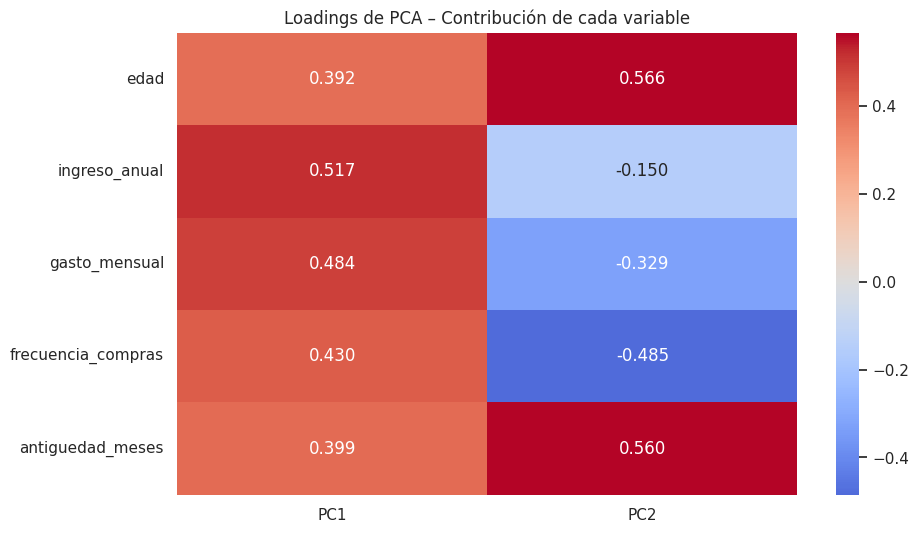

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'],
                        index=X_sin_cluster.columns)
print('Loadings de PCA:')
print(loadings.round(3))

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Loadings de PCA – Contribución de cada variable')
plt.show()

# Para la contribución miramos valor absoluto: |-0.70| es mayor que |0.20|.


**Interpretación:**

En cada componente, identificá las variables con mayor loading en valor absoluto. El signo marca dirección y puede invertirse sin modificar la solución matemática; importan la magnitud y las relaciones entre variables.
